# Forward inference diagnostics

This notebook compares baseline OLS forward and discount-factor estimates with a spread-weighted fit. It inspects parity residuals and quote quality without applying production filters.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

MATCHED_DATA_PATH = Path("../data/processed/spx_option_prices_matched_2025-08-29.csv")
FORWARD_DATA_PATH = Path("../data/processed/spx_forward_estimates_2025-08-29.csv")
GROUP_KEYS = ["security_id", "quote_date", "expiry_date"]

matched = pd.read_csv(MATCHED_DATA_PATH, parse_dates=["quote_date", "expiry_date"])
baseline = pd.read_csv(FORWARD_DATA_PATH, parse_dates=["quote_date", "expiry_date"])

matched.shape, baseline.shape

((7835, 21), (38, 9))

In [2]:
diagnostics = matched[matched["time_to_expiry"] > 0].copy()
diagnostics["parity_value"] = diagnostics["call_mid"] - diagnostics["put_mid"]
diagnostics["combined_spread"] = (
    diagnostics["call_ask"] - diagnostics["call_bid"]
    + diagnostics["put_ask"] - diagnostics["put_bid"]
)

diagnostics = diagnostics.merge(
    baseline[GROUP_KEYS + ["forward", "discount_factor"]],
    on=GROUP_KEYS,
    how="left",
    validate="many_to_one",
)
diagnostics["fitted_parity"] = diagnostics["discount_factor"] * (
    diagnostics["forward"] - diagnostics["strike"]
)
diagnostics["parity_residual"] = (
    diagnostics["parity_value"] - diagnostics["fitted_parity"]
)

diagnostics[["parity_residual", "combined_spread"]].describe()

,parity_residual,combined_spread
count,7.426000e+03,7426.000000
mean,7.266127e-13,10.424434
std,7.066173e-01,6.001982
min,-2.518084e+00,0.400000
25%,-5.120718e-01,6.700000
50%,-3.475467e-02,9.800000
75%,6.268606e-01,17.100000
max,3.054247e+00,43.200000


In [3]:
quote_quality = diagnostics.assign(
    zero_bid=(diagnostics["call_bid"].eq(0) | diagnostics["put_bid"].eq(0)),
    wide_spread=diagnostics["combined_spread"]
    >= diagnostics["combined_spread"].quantile(0.95),
)

quote_quality.groupby(["zero_bid", "wide_spread"])[
    ["parity_residual", "combined_spread"]
].agg(["count", "mean", "median"])

parity_residual                     combined_spread  \
                               count      mean    median           count   
zero_bid wide_spread                                                       
False    False                  6696  0.044334  0.010743            6696   
         True                    348 -0.253145 -0.390588             348   
True     False                   342 -0.579928 -0.578684             342   
         True                     40 -0.260767 -0.138784              40   

                                         
                           mean  median  
zero_bid wide_spread                     
False    False         9.524089   9.400  
         True         19.493103  18.600  
True     False        17.722807  17.850  
         True         19.843750  19.375

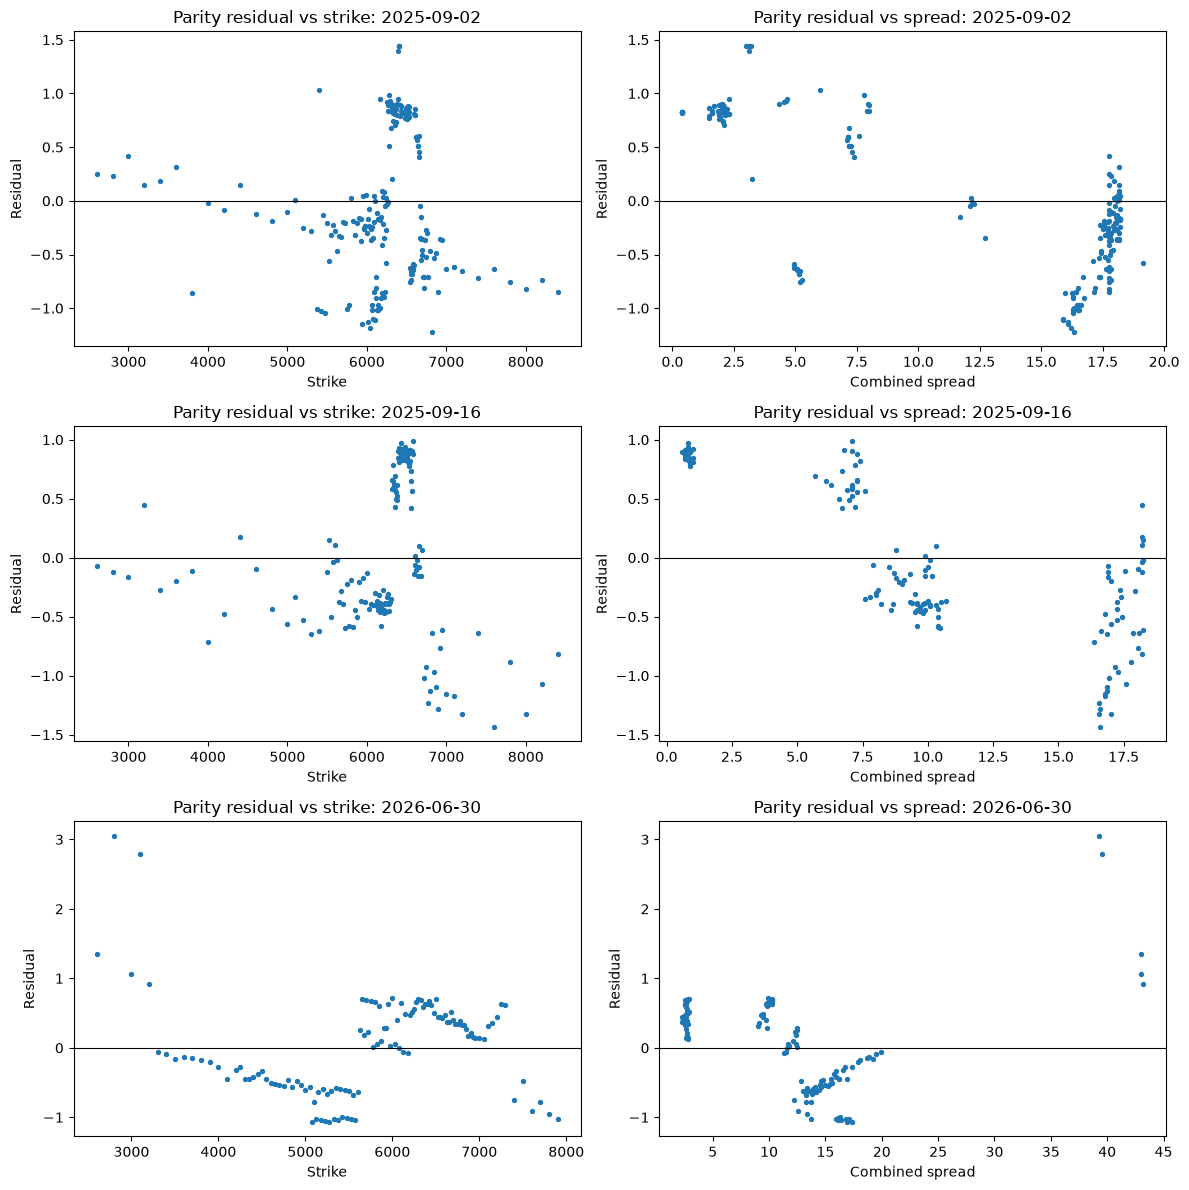

In [4]:
selected_expiries = (
    diagnostics["expiry_date"].drop_duplicates().sort_values().iloc[[0, 10, -1]]
)
fig, axes = plt.subplots(
    len(selected_expiries), 2, figsize=(12, 4 * len(selected_expiries))
)

for row, expiry in enumerate(selected_expiries):
    sample = diagnostics[diagnostics["expiry_date"] == expiry]

    axes[row, 0].scatter(sample["strike"], sample["parity_residual"], s=8)
    axes[row, 0].axhline(0, color="black", linewidth=0.8)
    axes[row, 0].set_title(f"Parity residual vs strike: {expiry.date()}")
    axes[row, 0].set_xlabel("Strike")
    axes[row, 0].set_ylabel("Residual")

    axes[row, 1].scatter(
        sample["combined_spread"], sample["parity_residual"], s=8
    )
    axes[row, 1].axhline(0, color="black", linewidth=0.8)
    axes[row, 1].set_title(f"Parity residual vs spread: {expiry.date()}")
    axes[row, 1].set_xlabel("Combined spread")
    axes[row, 1].set_ylabel("Residual")

plt.tight_layout()

The plots are diagnostic only. No zero-bid, wide-spread, or wing quotes are removed here.

In [5]:
def weighted_forward_and_discount_factor(group):
    group = group[group["combined_spread"] > 0]
    strikes = group["strike"].to_numpy(float)
    parity = group["parity_value"].to_numpy(float)
    sqrt_weights = 1 / group["combined_spread"].to_numpy(float)

    design = np.column_stack([np.ones(len(strikes)), strikes])
    weighted_design = design * sqrt_weights[:, None]
    weighted_parity = parity * sqrt_weights

    intercept, slope = np.linalg.lstsq(
        weighted_design,
        weighted_parity,
        rcond=None,
    )[0]

    discount_factor = -slope
    forward = intercept / discount_factor
    return forward, discount_factor


weighted_results = []
for keys, group in diagnostics.groupby(GROUP_KEYS):
    forward, discount_factor = weighted_forward_and_discount_factor(group)
    weighted_results.append({
        "security_id": keys[0],
        "quote_date": keys[1],
        "expiry_date": keys[2],
        "weighted_forward": forward,
        "weighted_discount_factor": discount_factor,
    })

weighted = pd.DataFrame(weighted_results)
comparison = baseline.merge(
    weighted,
    on=GROUP_KEYS,
    validate="one_to_one",
)
comparison["forward_change"] = (
    comparison["weighted_forward"] - comparison["forward"]
)
comparison["discount_factor_change"] = (
    comparison["weighted_discount_factor"]
    - comparison["discount_factor"]
)

comparison[[
    "expiry_date",
    "forward",
    "weighted_forward",
    "forward_change",
    "discount_factor",
    "weighted_discount_factor",
    "discount_factor_change",
]].head()

,expiry_date,forward,weighted_forward,forward_change,discount_factor,weighted_discount_factor,discount_factor_change
0,2025-09-02,6459.775231,6460.585983,0.810752,0.999663,0.999550,-0.000113
1,2025-09-03,6460.607204,6461.339998,0.732794,0.999534,0.999341,-0.000193
2,2025-09-04,6460.674144,6461.603618,0.929474,0.999425,0.999148,-0.000277
3,2025-09-05,6462.397265,6463.335261,0.937996,0.999110,0.998858,-0.000252
4,2025-09-08,6463.129026,6463.807532,0.678507,0.998829,0.998715,-0.000114


In [6]:
comparison[["forward_change", "discount_factor_change"]].describe()

,forward_change,discount_factor_change
count,38.000000,38.000000
mean,0.841582,-0.000344
std,0.201313,0.000168
min,0.343109,-0.000660
25%,0.735617,-0.000443
50%,0.863441,-0.000341
75%,0.942376,-0.000252
max,1.358377,0.000002
